In [2]:
import qiskit
qiskit.__qiskit_version__

{'qiskit-terra': '0.19.2', 'qiskit-aer': '0.10.3', 'qiskit-ignis': '0.7.0', 'qiskit-ibmq-provider': '0.18.3', 'qiskit-aqua': None, 'qiskit': '0.34.2', 'qiskit-nature': None, 'qiskit-finance': None, 'qiskit-optimization': None, 'qiskit-machine-learning': None}

In [3]:
from qiskit import IBMQ
IBMQ.save_account('API TOKEN here!')

configrc.store_credentials:WARNING:2023-01-01 17:46:21,329: Credentials already present. Set overwrite=True to overwrite.


In [4]:
IBMQ.load_account()

<AccountProvider for IBMQ(hub='ibm-q', group='open', project='main')>

In [5]:
from qiskit import IBMQ

api_key = None
for attempt in range(3):
    try:
        if api_key:
            IBMQ.save_account(api_key, overwrite=True)
        else:
            IBMQ.load_account()
        break
    except Exception:
        api_key = input("Enter IBMQ API Key (attempt %s): " % attempt)

ibmqfactory.load_account:WARNING:2023-01-01 17:47:27,476: Credentials are already in use. The existing account in the session will be replaced.


In [6]:
# second gist

from qiskit import *

In [7]:
qr = QuantumRegister(2)
cr = ClassicalRegister(2)

In [8]:
circuit = QuantumCircuit(qr, cr)
%matplotlib inline

In [9]:
circuit.draw()

q0_0: 
      
q0_1: 
      
c0: 2/

In [10]:
circuit.h(qr[0])

In [11]:
circuit.draw()

┌───┐
q0_0: ┤ H ├
      └───┘
q0_1: ─────
           
c0: 2/═════

In [12]:
circuit.cx(qr[0], qr[1])

In [13]:
circuit.draw()

┌───┐     
q0_0: ┤ H ├──■──
      └───┘┌─┴─┐
q0_1: ─────┤ X ├
           └───┘
c0: 2/══════════

In [14]:
circuit.measure(qr, cr)

In [15]:
circuit.draw()

┌───┐     ┌─┐   
q0_0: ┤ H ├──■──┤M├───
      └───┘┌─┴─┐└╥┘┌─┐
q0_1: ─────┤ X ├─╫─┤M├
           └───┘ ║ └╥┘
c0: 2/═══════════╩══╩═
                 0  1

In [16]:
simulator = Aer.get_backend('qasm_simulator')
execute(circuit, backend = simulator)

In [17]:
result = execute(circuit, backend = simulator).result()

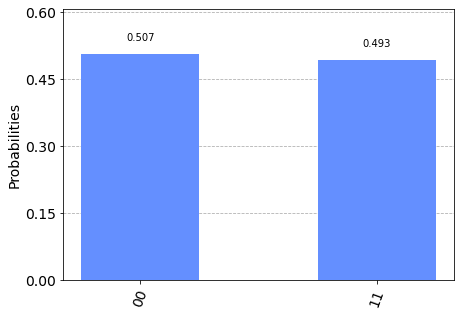

In [18]:
from qiskit.tools.visualization import plot_histogram
plot_histogram(result.get_counts(circuit))

In [ ]:
IBMQ.load_account()
provider = IBMQ.get_provider('ibm-q')
qcomp = provider.get_backend('ibmq_16_malbourne')
job = execute(circuit, backend=qcomp)

In [ ]:
from qiskit.tools.monitor import job_monitor
job_monitor(job)
result = job.result()
plot_histogram(result.get_counts(circuit))